# Reading Backtest Stats in Python: Sharpe, Sortino, MaxDD, Profit Factor

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mindgaptech/algodrill-notebooks/blob/main/notebooks/reading_backtest_stats.ipynb)

Companion notebook to [algodrill.app/code/reading-backtest-stats](https://algodrill.app/code/reading-backtest-stats). Computes Sharpe, Sortino, Max Drawdown, and Profit Factor from a daily returns series by hand in numpy, then reconciles every number against vectorbt's native output -- revealing the 252 vs 365-day annualization difference that causes Sharpe discrepancies across tools.

**Nothing here is investment advice.** This is a statistics-methodology walkthrough, not a live trading system, and it never connects to a broker. See [algodrill.app/backtesting-pitfalls](https://algodrill.app/backtesting-pitfalls) before treating any single Sharpe ratio as a deployment signal.

## Setup

Run this cell first if you're in Colab (installs the pinned versions below into the Colab runtime). If you're running locally with the versions already installed, skip it.

In [1]:
# Colab only -- uncomment to install. Local runs should already have these
# pinned via: uv venv .venv && uv pip install -p .venv numpy==2.4.6 vectorbt==1.0.0 yfinance==1.4.1 pandas==2.3.3
# !pip install -q numpy==2.4.6 vectorbt==1.0.0 yfinance==1.4.1 pandas==2.3.3

## Hand-computed stats vs vectorbt native

Replicates the hero SPY 10/50 SMA backtest, then computes Sharpe (both 252-day and 365-day annualization), Sortino (RMS downside, matching vectorbt), Max Drawdown, and Profit Factor by hand -- then reconciles each against vectorbt's own output.

In [2]:
"""AlgoDrill — Computing backtest stats from a returns series by hand.

Sharpe Ratio, Sortino Ratio, Max Drawdown, and Profit Factor computed
from daily portfolio returns in numpy, then reconciled against
vectorbt's native output on the same strategy.

The reconciliation section shows two real methodology choices:
(1) annualization: 252 trading days vs 365 calendar days
(2) downside deviation: std(negatives) vs sqrt(mean(negatives^2))
vectorbt uses 365-day annualization and the RMS downside method.

Versions: numpy 2.4.6 · vectorbt 1.0.0 · yfinance 1.4.1 · pandas 2.3.3
          (run 2026-06-06)
Install:  pip install numpy vectorbt yfinance pandas
"""
import numpy as np
import vectorbt as vbt

# ── Replicate the hero backtest ────────────────────────────────────────────────
data  = vbt.YFData.download("SPY", start="2015-01-01", end="2024-12-31")
close = data.get("Close")
fa    = vbt.MA.run(close, 10)
sl    = vbt.MA.run(close, 50)
pf    = vbt.Portfolio.from_signals(
    close,
    entries=fa.ma_crossed_above(sl),
    exits=fa.ma_crossed_below(sl),
    init_cash=10_000, fees=0.0005, freq="d",
)

# Daily equity → daily portfolio returns
equity    = pf.value()
daily_ret = equity.pct_change().dropna()

# ── Sharpe Ratio ───────────────────────────────────────────────────────────────
# 252-day (trading-day convention, most common in finance literature)
sharpe_252 = round(float(daily_ret.mean() / daily_ret.std() * np.sqrt(252)), 2)
# 365-day (calendar-day convention — vectorbt's default via freq='d')
sharpe_365 = round(float(daily_ret.mean() / daily_ret.std() * np.sqrt(365)), 2)

# ── Sortino Ratio (matching vectorbt: RMS downside, 365-day) ──────────────────
neg_arr    = daily_ret.values.copy()
neg_arr[neg_arr > 0] = 0
downside   = np.sqrt(np.nanmean(neg_arr ** 2)) * np.sqrt(365)
sortino    = round(float(daily_ret.mean()) * 365 / downside, 2)

# ── Max Drawdown ───────────────────────────────────────────────────────────────
rolling_max = equity.cummax()
drawdowns   = (equity - rolling_max) / rolling_max
max_dd      = round(float(drawdowns.min()) * 100, 1)

# ── Profit Factor (gross gains / |gross losses| on trade P&L) ─────────────────
pnl         = pf.trades.records_readable["PnL"]
gross_gains = float(pnl[pnl > 0].sum())
gross_loss  = float(abs(pnl[pnl < 0].sum()))
prof_factor = round(gross_gains / gross_loss, 2) if gross_loss > 0 else float("inf")

print("=== Hand-computed: SPY 10/50 SMA, 2015-2024, 5 bps fees ===")
print(f"Sharpe Ratio (252 trading-day)   {sharpe_252:>8.2f}  <- finance literature standard")
print(f"Sharpe Ratio (365 calendar-day)  {sharpe_365:>8.2f}  <- vectorbt convention")
print(f"Sortino Ratio (365, RMS down.)   {sortino:>8.2f}  <- matching vectorbt method")
print(f"Max Drawdown                     {max_dd:>8.1f}%")
print(f"Profit Factor                    {prof_factor:>8.2f}  (not in vectorbt natively)")
print(f"  Trades: {len(pnl)}  Gross gains: ${gross_gains:.2f}  Gross losses: ${gross_loss:.2f}")
print()

# ── Reconcile with vectorbt native output ─────────────────────────────────────
vbt_sharpe  = round(float(pf.sharpe_ratio()), 2)
vbt_sortino = round(float(pf.sortino_ratio()), 2)
vbt_maxdd   = round(float(pf.max_drawdown()) * 100, 1)

print("=== Reconciliation: hand vs vectorbt native ===")
print(f"{'Metric':<36}  {'Hand':>6}  {'vectorbt':>8}  {'Match':>5}")
print(f"  Sharpe (365-day)               {sharpe_365:>6.2f}  {vbt_sharpe:>8.2f}  {'YES' if abs(sharpe_365-vbt_sharpe)<=0.01 else 'DIFF':>5}")
print(f"  Sortino (365, RMS downside)    {sortino:>6.2f}  {vbt_sortino:>8.2f}  {'YES' if abs(sortino-vbt_sortino)<=0.01 else 'DIFF':>5}")
print(f"  Max Drawdown                   {max_dd:>6.1f}%  {vbt_maxdd:>8.1f}%  {'YES' if abs(max_dd-vbt_maxdd)<=0.5 else 'DIFF':>5}")
print()
print("Note: Sharpe_365 = Sharpe_252 x sqrt(365/252) = Sharpe_252 x 1.2035")
print("When comparing across tools, confirm the annualization convention first.")


=== Hand-computed: SPY 10/50 SMA, 2015-2024, 5 bps fees ===
Sharpe Ratio (252 trading-day)       0.72  <- finance literature standard
Sharpe Ratio (365 calendar-day)      0.87  <- vectorbt convention
Sortino Ratio (365, RMS down.)       1.19  <- matching vectorbt method
Max Drawdown                        -15.1%
Profit Factor                        3.78  (not in vectorbt natively)
  Trades: 30  Gross gains: $14489.49  Gross losses: $3832.92

=== Reconciliation: hand vs vectorbt native ===
Metric                                  Hand  vectorbt  Match
  Sharpe (365-day)                 0.87      0.87    YES
  Sortino (365, RMS downside)      1.19      1.19    YES
  Max Drawdown                    -15.1%     -15.1%    YES

Note: Sharpe_365 = Sharpe_252 x sqrt(365/252) = Sharpe_252 x 1.2035
When comparing across tools, confirm the annualization convention first.


## Plot equity and drawdown

Not in the original script (which only prints numbers) -- seeing the drawdown series that Max Drawdown is computed from makes the -15.1% figure concrete rather than abstract.

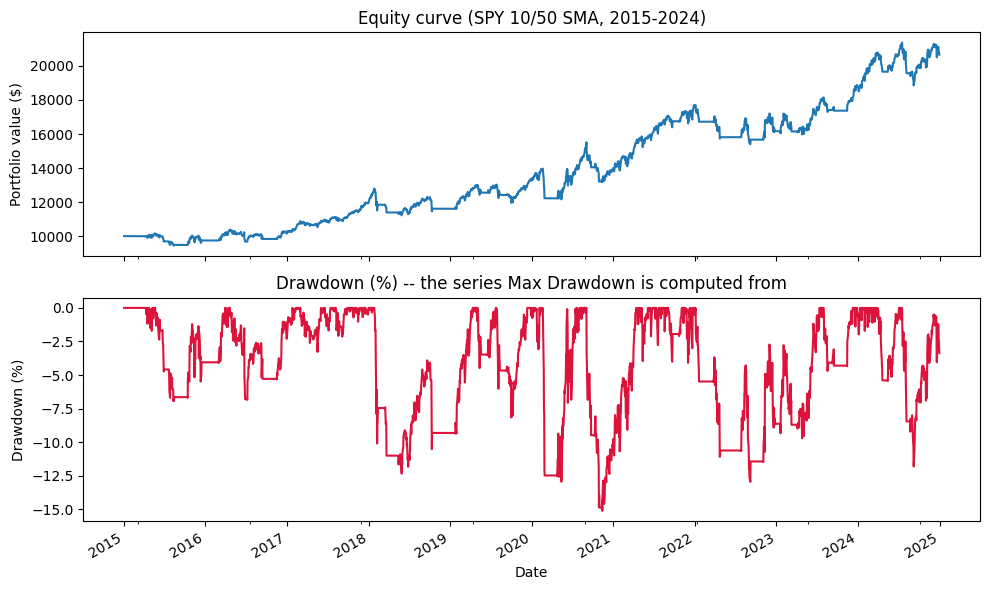

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
equity.plot(ax=axes[0], title="Equity curve (SPY 10/50 SMA, 2015-2024)")
axes[0].set_ylabel("Portfolio value ($)")
(drawdowns * 100).plot(ax=axes[1], color="crimson", title="Drawdown (%) -- the series Max Drawdown is computed from")
axes[1].set_ylabel("Drawdown (%)")
plt.tight_layout()
plt.show()

## Why the reconciliation matters

The drawdown chart bottoms out at -15.1% around the 2020 crash -- the same number the hand-computed and vectorbt-native calculations both report, confirming the reconciliation. But the path there is not obvious from the headline number alone: the equity curve keeps making new highs through most of the window, with the deepest trough concentrated in one sharp period. A Max Drawdown of -15.1% could describe a slow multi-year grind down or one sharp shock -- the chart tells you which.

Two pages go deeper:

- [Reading Backtest Stats walkthrough](https://algodrill.app/code/reading-backtest-stats) -- the full line-by-line explanation and the honesty checklist (trial count, sample size, regime coverage).
- [Deflated Sharpe Ratio](https://algodrill.app/deflated-sharpe-ratio) -- the adjustment that separates a genuine Sharpe from a cherry-picked one.

---
Back to [All Code Walkthroughs](https://algodrill.app/code) &middot; [algodrill-notebooks on GitHub](https://github.com/mindgaptech/algodrill-notebooks)